<a href="https://colab.research.google.com/github/AndrewDavidRatnam/HuggingFace_IntroToAudioCourse/blob/main/HF_AudioCourse_Unit_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# WHATS A TRANSFORMER?


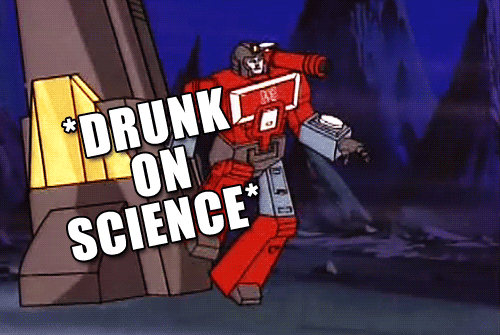


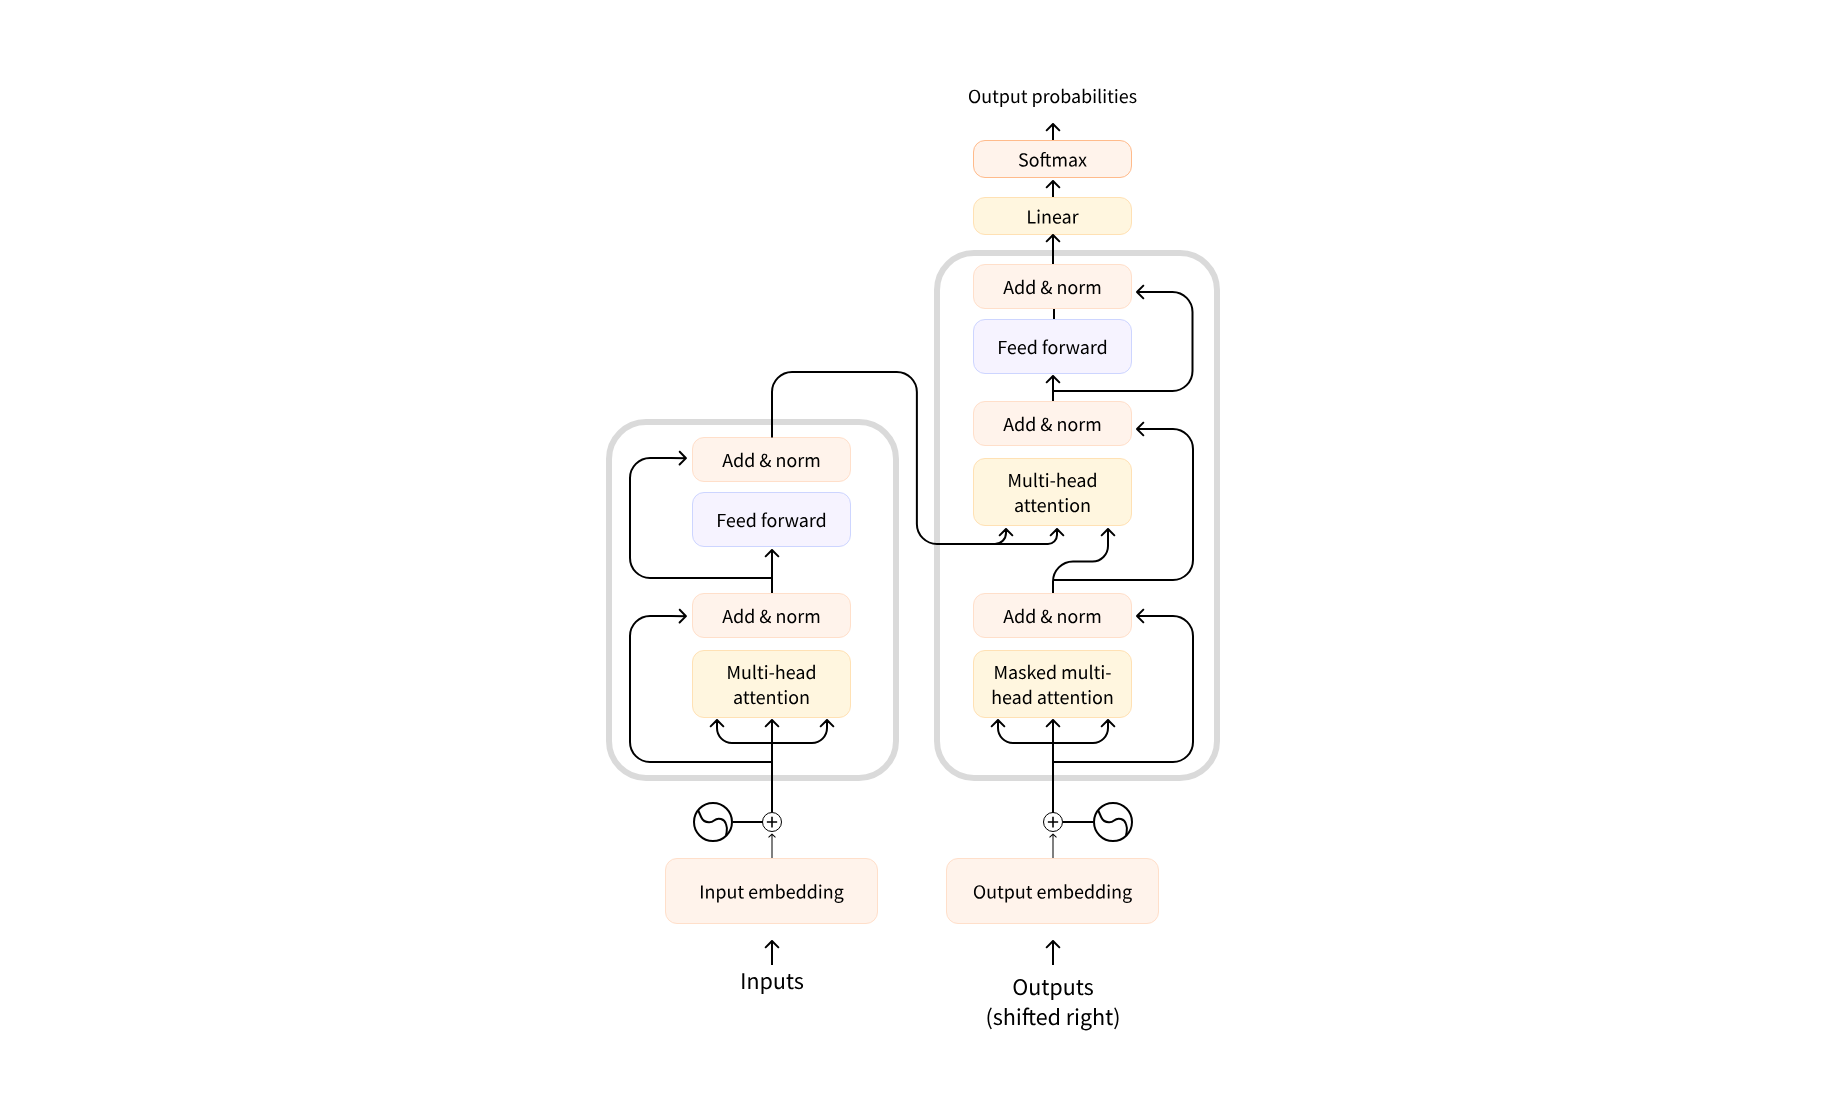

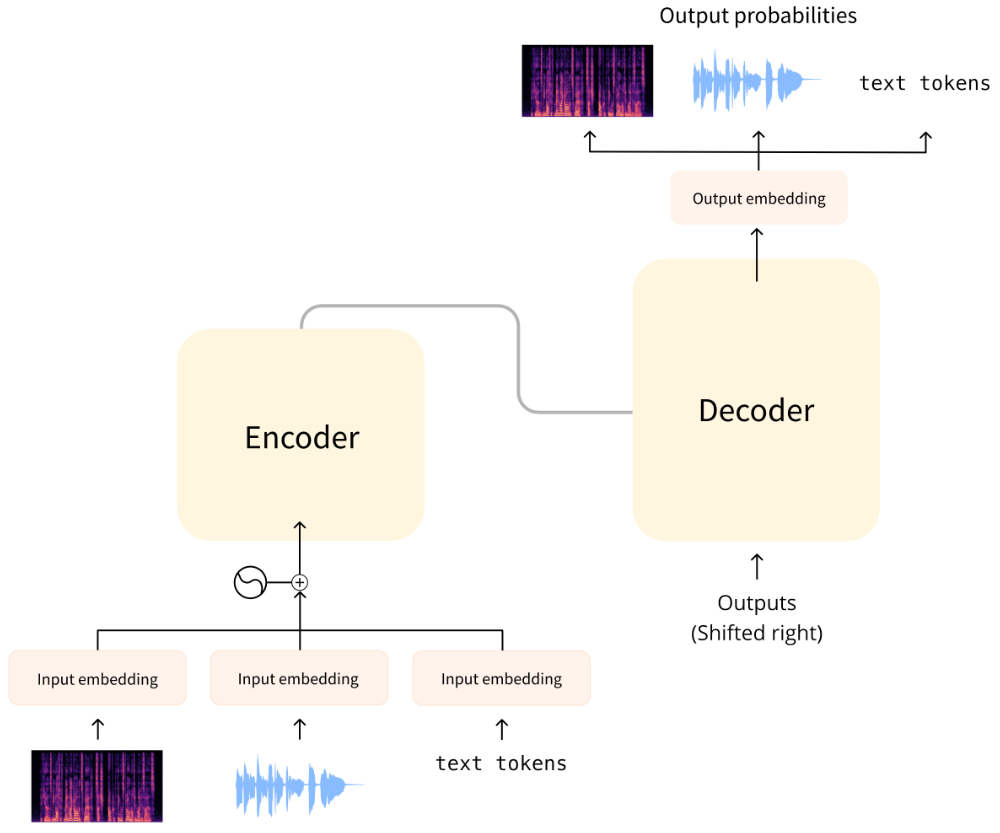

## Self Attention Head

In [15]:
import torch, torch.nn as nn
import torch.nn.functional as F
import math

class ScaledDotProductAttention(nn.Module):
  def forward(self, Q, K, V, mask=None):
    d_k = Q.size(-1)

    scores = torch.matmul(Q, K.transpose(-2, -1))/ math.sqrt(d_k) #the QK^t step

    if mask:
      scores = scores.masked_fill(mask == 0, float("-inf"))

      attn_weights = F.softmax(scores, dim=-1)

      output = torch.matmul(attn_weights, V)

      return output, attn_weights

## Multihead Attention used in almost every transformer block

In [9]:
class MultiHeadAttention(nn.Module):
  def __init__(self, d_model=512, num_heads=8):
    super().__init__()
    self.d_k = d_model // num_heads
    self.num_heads = num_heads
    self.W_q = nn.Linear(d_model, d_model)
    self.W_k = nn.Linear(d_model, d_model)
    self.W_v = nn.Linear(d_model, d_model)
    self.W_o = nn.Linear(d_model, d_model)
    self.attention = ScaledDotProductAttention()

  def split_heads(self, x):
    B, T, D = x.shape
    return x.view(B, T, self.num_heads, self.d_k).transpose(1, 2)

  def forward(self, Q, K, V, mask=None):
    Q = self.split_heads(self.W_q(Q))
    K = self.split_heads(self.W_k(K))
    V = self.split_heads(self.W_v(V))

    out, _ = self.attention(Q,K,V,mask)
    B, H, T, dk = out.shape
    out = out.transpose(1,2).contiguous().view(B,T,H*dk)
    return self.W_o(out)




## Postion Wise Feed Forward

In [10]:
class PostionWiseFeedForward(nn.Module):
  def __init__(self, d_model=512, d_ff=2048, dropout=0.1):
    super().__init__()
    self.w_1 = nn.Linear(d_model, d_ff)
    self.w_2 = nn.Linear(d_ff, d_model)
    self.dropout = nn.Dropout(dropout)
    self.activation = nn.GELU()

  def forward(self, x):
    #(Batchsize, seq_len, d_modek)
    return self.w2(
        self.dropout(
        self.activation(
            self.w_1(x)
            )))


# CTC: Connectionist Temporal Classification Architecture
Wav2Vec/HuBERT etc

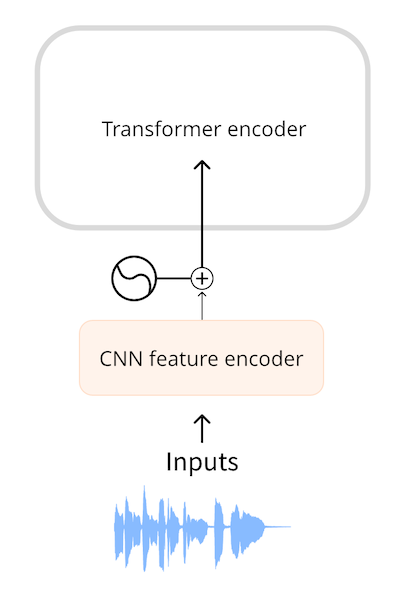

Only an Encoder and lowk classification head(Linear CTC) that outputs characters like 50(26 and some special tokens)

It’s also possible for models to directly output a waveform instead of a spectrogram as an intermediate step, but we currently don’t have any models in 🤗 Transformers that do this.<br>
Key Milestones:
- The Foundation (2016): WaveNet proved that neural networks could synthesize raw audio at 16kHz sample rates, though it was computationally expensive at the time.
- The Codec Era (2021-2022): Models like SoundStream and EnCodec revolutionized the field by compressing audio into discrete tokens, allowing later models to "predict" audio like text.
- Zero-Shot Breakthroughs (2023): Microsoft’s VALL-E used these discrete tokens to achieve high-quality voice cloning from just a three-second sample.
- Current SOTA (2024): Modern research focuses on speed, with PeriodWave-Turbo and others moving toward single-step generation that is fast enough for real-time mobile applications.



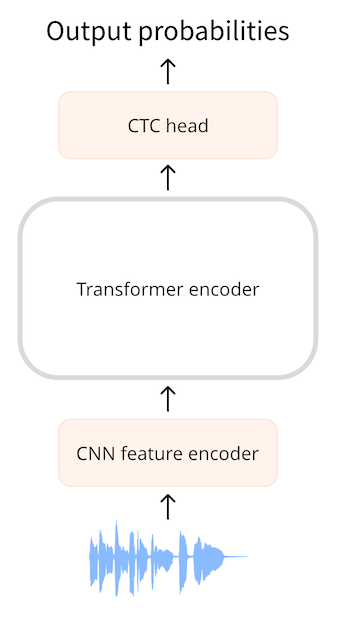

## CNN Feature Encoder

In [11]:
class Wav2Vec2_CNNEncoder(nn.Module):
  # (Batch, 1, num_samples)(1 sec) --> (Batch, T, 512) (T is 50 as 1 vec per 20ms)

  def __init__(self):
    super().__init__()
    conv_params = [
        (512,10,5),(512,3,2),(512,3,2),(512,3,2),(512, 3, 2),(512, 2, 2),(512, 2, 2)
    ]
    layers, in_ch = [], 1
    for out_ch, k , s in conv_params: #out, kernel, stride
      layers +=[nn.Conv1d(in_ch,out_ch, kernel_size = k ,stride = s), nn.GELU]
      in_ch = out_ch

    self.conv = nn.Sequential(*layers)

  def forward(self, waveform):
    x = waveform.unsqueeze(1) #(B, T) --> (B,1,T)
    x = self.conv(x)
    return x.transpose(1, 2) # (B, T', 512)

class TransformerEncoderBlock(nn.Module):

  def __init__(self, d_model=768, num_heads = 12,
               ff_dim=3072, dropout=0.3):

    super().__init__()
    self.self.attn = MultiHeadAttention(d_model, num_heads=num_heads)

    self.ff = nn.Sequential(
        nn.Linear(d_model, ff_dim),
        nn.GELU(),
        nn.Linear(ff_dim, d_model),
    )

    self.norm_1 = nn.LayerNorm(d_model)
    self.norm_2 = nn.LayerNorm(d_model)

    self.drop = nn.Dropout(dropout)

  def forward(self, x):
    #multihead self attention
    attn_out = self.self_attn(x, x, x)
    x = self.norm_1(x + self.drop(attn_out))

    ff_out = self.ff(x)

    x = self.norm_2(x + self.drop(x))

    return x


class CTCHEAD(nn.Module):

  def __init__(self,d_model=768, vocab_size=32):
    super().__init__()
    self.linear = nn.Linear(d_model, vocab_size)


  def forward(self, hidden_states):
    return self.linear(hidden_states)


def ctc_decode(logits, blank_id=0):

  pred_ids = torch.argmax(logits, dim=-1)

  results = []
  for seq in pred_ids:
    tokens = []
    prev = None

    for t in seq.tolist():
      if t != blank_id and t != prev:
        tokens.append(t)
      prev = t
    results.append(tokens)

  return results


def beam_decode(logits, blank_id = 0):
  pass #revise and implement vectorized






<h3> Beam Search<h3>

```python
import torch
import torch.nn.functional as F

def simple_beam_search(logits, beam_size=3, blank_id=0):
    """
    A basic CTC Beam Search decoder.
    logits: (Time, Vocab) tensor of log-probabilities
    """
    T, V = logits.shape
    # Initial beam: [(sequence_tuple, log_probability)]
    # Start with an empty sequence and 0 log-prob (which is 1.0 probability)
    beams = [(tuple(), 0.0)]

    for t in range(T):
        all_candidates = []
        step_log_probs = logits[t] # Log-probs for this timestep

        for seq, score in beams:
            for char_id in range(V):
                # Calculate new score: Current Score + Log-Prob of this character
                new_score = score + step_log_probs[char_id].item()
                
                # Rule 1: If blank, don't add to the string
                if char_id == blank_id:
                    new_seq = seq
                # Rule 2: If same as last char, only add if there's a blank between
                # (Simplified here: we just append to show the logic)
                elif len(seq) > 0 and char_id == seq[-1]:
                    new_seq = seq # Greedy logic would merge; real CTC uses blank state
                else:
                    new_seq = seq + (char_id,)
                
                all_candidates.append((new_seq, new_score))

        # Merge duplicate sequences by summing probabilities
        # Since we use log-probs, we use torch.logsumexp for precision
        merged = {}
        for seq, score in all_candidates:
            if seq not in merged:
                merged[seq] = score
            else:
                # Basic sum in probability space: log(exp(a) + exp(b))
                merged[seq] = torch.logsumexp(torch.tensor([merged[seq], score]), dim=0).item()

        # Sort by score and keep the top 'beam_size'
        beams = sorted(merged.items(), key=lambda x: x[1], reverse=True)[:beam_size]

    return beams

# Example Usage:
# Suppose we have 2 timesteps and a vocab of 3 (0=blank, 1='A', 2='B')
example_logits = torch.log(torch.tensor([
    [0.1, 0.6, 0.3], # T1: 'A' is most likely
    [0.1, 0.2, 0.7]  # T2: 'B' is most likely
]))

top_beams = simple_beam_search(example_logits, beam_size=2)
print("Top sequences and their log-scores:", top_beams)


```
## BEAM SEARCH VECTORIZED

``` python
import torch

def vectorized_beam_step(beam_log_probs, step_log_probs, beam_size):
    """
    beam_log_probs: (beam_size,) - Current log-probs of each sequence in the beam
    step_log_probs: (vocab_size,) - Model's log-probs for the current audio frame
    """
    # 1. Expand scores for ALL possible next characters across ALL beams at once
    # Resulting shape: (beam_size, vocab_size)
    # This replaces: for seq, score in beams: for char_id in range(V):
    all_candidate_scores = beam_log_probs.unsqueeze(1) + step_log_probs.unsqueeze(0)

    # 2. Flatten to (beam_size * vocab_size) and find the best globally
    flat_scores = all_candidate_scores.view(-1)
    
    # 3. Use topk to find the new beam in one shot
    # This replaces the sorting and slicing: sorted(... items())[:beam_size]
    top_scores, top_indices = torch.topk(flat_scores, k=beam_size)

    # 4. Math to figure out which parent beam and character won
    vocab_size = step_log_probs.size(0)
    parent_beam_indices = top_indices // vocab_size
    chosen_char_indices = top_indices % vocab_size

    return top_scores, parent_beam_indices, chosen_char_indices

```

## Seq2Seq Architectures

Whisper CNN

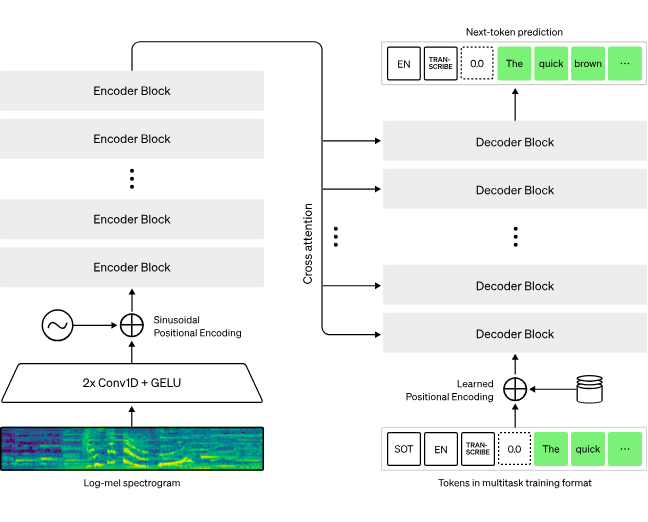

- formula yaad karna hi hai$$O = \left\lfloor \frac{I - K + 2P}{S} \right\rfloor + 1$$

- For a Transposed Convolution (often used for upsampling or "deconvolution"), the formula is:<br>
$$O = (I - 1) \times S - 2P + D \times (K - 1) + OutP + 1$$
<br>
Where $OutP$ is the output padding (used to resolve ambiguities when the stride is greater than 1).









In [13]:
class WhisperConvFrontend(nn.Module):

  def __init__(self, d_model = 512):

    self.conv_1 = nn.Conv1d(80, d_model, kernel_size=3,
                            padding=1)
    self.conv_2 = nn.Conv1d(d_model, d_model, kernel_size =3 ,
                            stride=2, padding = 1)
    self.gelu = nn.GELU()


  def forward(self, mel):

    x = self.gelu(self.conv_1(mel))
    x = self.gelu(self.conv2(x))
    x = x.transpose(1,2)

    return x

class CrossAttention(nn.Module):
  """
  Q --> from the decoder hidden states
  What am i Looking for?

  K --> from the encoder hidden states
  What keys are available?

  V --> from the decoder hidden states
  What values to retrieve?


  """

  def __init__(self, d_model=512,
               num_heads = 8):
    self.attn = MultiHeadAttention(d_model,
                                   num_heads=num_heads)


  def forward(self, decoder_hidden, encoder_output):
    return self.attn(
        Q = decoder_hidden,  #(B, T_enc, d_model)
        K = encoder_output,  #(B, T_enc, d_model)
        V = encoder_output
    )



def casual_mask(seq_len, device):
  """
  lower trig matrix with ones of seq_length
  """
  return torch.tril(torch.ones(seq_len, seq_len,
                               device = device))



class DecoderBlock(nn.Module):

# This is the bread and butter
  def __init__(self,d_model=512, num_heads=8, ff_dim=2048):
    super().__init__()
    self.self_attn = MultiHeadAttention(d_model, num_heads)
    self.cross_attn = CrossAttention(d_model, num_heads)
    self.ff = nn.Sequential(
        nn.Linear(d_model, ff_dim),
        nn.GELU(),
        nn.Linear(ff_dim, d_model)
    )

    self.norm_1 = nn.LayerNorm(d_model)
    self.norm_1 = nn.LayerNorm(d_model)
    self.norm_3 = nn.LayerNorm(d_model)

  def forward(self, x, encoder_out):
    T = x.size(1)
    mask = casual_mask(T, x.device)

    x = self.norm_1(x + self.self_attn(x,x,x, mask))

    x = self.norm_2(x + self.cross_attn(x, encoder_out))

    x = self.norm_3(x + self.ff(x))

    return x

class Decoder(nn.Module):
  def __init__(self,embedder):
    self.embed_tokens = embedder
    self.blocks = nn.Sequential(
        DecoderBlock(),
        DecoderBlock(),
        DecoderBlock()
        )

    def forward():
      pass
#something

def whisper_decode(encoder_out, decoder, lm_head, tokenizer,
                   max_steps=448, eos_id=50527): #end sequence id , start sequence is 1

  generated = [tokenizer.sot_token_id]
  for _ in range(max_steps):
    token_ids = torch.tensor([generated])
    embeddings = decoder.embed_tokens(token_ids) #this we did not create?

    dec_out = embeddings

    for block in decoder.blocks:
      dec_out = block(dec_out, encoder_out)

    logits = lm_head(dec_out, encoder_out)
    next_token = logits.argmax(dim=-1).item()

    if next_token == eos_id:
      break
    generated.append(next_token)

  return tokenizer.decode(generated[1:]) #first is start of sequence token


class SpeechT5SpectogramDecoder(nn.Module):
  #786 --> Linear --> log mel (80)
  def __init__(self, d_model=768, n_mels=80):
    super().__init__()

    self.mel_linear = nn.Linear(d_model, n_mels)

    self.postnet = nn.Sequential(
        nn.Conv1d(n_mels, 512, kernel_size=5, padding=2), nn.Tanh(),
        nn.Conv1d(512, 512, kernel_size=5, padding=2),nn.Tanh(),
        nn.Conv1d(512, 512, kernel_size=5, padding=2),nn.Tanh(),
        nn.Conv1d(512, 512, kernel_size=5, padding=2),nn.Tanh(),
        nn.Conv1d(512, n_mels, kernel_size=5, padding=2)
        )
    self.stop_predictor = nn.Linear(d_model, 1)

  def forward(self, decoder_hidden):
    mel_frames = self.mel_linear(decoder_hidden)
    stop_prob = torch.sigmoid(
        self.stop_predictor(decoder_hidden)
    )
    mel_t = mel_frames.transpose(1, 2)
    mel_refined = mel_frames + self.postnet(mel_t).transpose(1, 2)

    return mel_refined, stop_prob











# Audio Classification AST

In [16]:
class AudioSpectrogram(nn.Module):
  def __init__(self, TransformerEncoderBlock, freq_bins = 128, time_frames=1024, patch_size=16,
               d_model=768, num_classes=527, ):
    super().__init__()

    self.patch_embed = nn.Conv2d(
        in_channels = 1,
        out_channels=d_model,
        kernel_size=patch_size,
        stride=10,
    )
    self.cls_token = nn.Parameter(torch.zeros(1, 1, d_model))

    self.encoder = nn.Sequential(

                       *[TransformerEncoderBlock(d_model) for _ in range(12)]
    )
    self.classifier = nn.Sequential(
        nn.LayerNorm(d_model),
        nn.Linear(d_model, num_classes),
        nn.Sigmoid() #multilabel ; use softmax for single label
    )

  def forward(self, spec):
    x = self.patch_embed(spec)  #(B, d_model, H', W')

    B,D,H,W = x.shape
    x = x.flatten(2).transpose(1,2) #(B, num_patched, d_model)

    cls = self.cls_token.expand(B, -1, -1)

    x = torch.cat([cls, x], dim=1)

    x = torch.cat([cls, x ], dim=1)

    x = self.encoder(x)

    return self.classifier(x[:, 0, :])

In [17]:
class Wav2Vec2_SequenceClassification(nn.Module):
  #takes all hidden states and then classifies

  def __init__(self, encoder, d_model=764, num_classes=None):
    super().__init__()
    self.encoder = encoder
    self.classifier = nn.Linear(d_model, num_classes)

  def forward(self, waveform):
    hidden_states = self.encoder(waveform)
    pooled = hidden_states.mean(dim=1)
    return self.classifier(pooled)


class Wav2Vec2AudioFrameClassification(nn.Module):
  #predicts one label per frame
  def __init__(self, encoder, d_model = 768, num_classes=None):
    super().__init__()
    self.encoder = encoder
    self.classifier = nn.Linear(d_model, num_classes)

  def forward(self, waveform):
    hidden_states = self.encoder(waveform)
    return self.classifier(hidden_states)





## 5. 🔁 Architecture Comparison Summary

| Feature | CTC (Wav2Vec2/HuBERT) | Seq2Seq (Whisper/SpeechT5) | AST |
|---|---|---|---|
| Encoder | ✅ | ✅ | ✅ |
| Decoder | ❌ | ✅ | ❌ |
| Cross-Attention | ❌ | ✅ | ❌ |
| Causal Mask | ❌ | ✅ (decoder) | ❌ |
| Input | Raw waveform (CNN) | Spectrogram (CNN) | Spectrogram (patches) |
| Output | Characters (small vocab) | Tokens (50k+ vocab) | Class labels |
| Alignment | CTC blank token | Cross-attention | N/A |
| Speed | Fast (parallel) | Slow (autoregressive) | Fast (parallel) |
| Eval Metric | WER | WER | Accuracy / mAP |

---

## ❓ Quiz Answers

**1. What is a vocoder?**
✅ **An additional neural network that turns the spectrogram output of a transformer into a waveform.**
> A vocoder is needed because models like SpeechT5 only predict the amplitude portion of the spectrogram — not the phase. The vocoder estimates the missing phase information and reconstructs the audio waveform. The inverse STFT alone cannot do this since the phase is lost.

---

**2. Wav2Vec2 is an example of:**
✅ **CTC architecture**
> Wav2Vec2 uses an encoder-only transformer with a CTC head on top. It takes raw waveforms as input via a CNN feature encoder, then predicts characters with a linear CTC head.

---

**3. What does a blank token in CTC do?**
✅ **Blank token is a predicted token that serves as a hard boundary between groups of characters. It makes it possible to filter out duplicate characters.**
> Without the blank token, `"LL"` and `"L"` would be indistinguishable after collapsing duplicates. The blank token separates character groups: `L_L` → two L's, `LL` → one L.

---

**4. Which statement about CTC models is FALSE?**
✅ **CTC models tend to perform best for speech recognition compared to other architectures.**
> This is FALSE. Seq2Seq models like Whisper generally achieve superior performance because they use a full decoder with cross-attention and a large token vocabulary (50k+), enabling richer language modeling. CTC models are faster but typically less accurate.

---

**5. Whisper is an example of:**
✅ **Seq2Seq architecture**
> Whisper uses a full encoder-decoder transformer. The encoder processes a log-mel spectrogram; the decoder autoregressively generates text tokens using cross-attention over the encoder's output.

---

**6. What is the easiest way to perform audio classification?**
✅ **Use spectrograms and treat the task as an image classification problem.**
> A spectrogram is a 2D tensor `(freq, time)` that can be passed directly into image models like ViT or ResNet. This is exactly what AST (Audio Spectrogram Transformer) does, and it achieves strong results.

---

**7. True or false? When treating spectrograms as images, you will always benefit from image augmentation techniques like shifting, cropping, or resizing.**
✅ **False**
> Unlike images, spectrograms are **not translation-invariant**. Shifting a spectrogram vertically changes the frequencies (pitch) and fundamentally alters the sound. Some augmentations (like SpecAugment — masking frequency bands or time steps) are appropriate, but general image augmentations must be applied carefully.